In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import regularizers
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
import h5py


In [2]:
def h5_to_dataframe(file_path, dataframe):
    ''' 
    Function for converting h5 file to a pandas dataframe for analysis 
    file_path: path to the h5 file, must be a string
    Dataframe_name: name of the pre-defined dataframe
    
    '''
    with h5py.File(file_path, mode='r') as file:
        tasks_group = file['tasks']
    
        keys = list(tasks_group.keys())
        keys.remove('visc_dissip')
        keys.remove('Reavg')
        time = np.array(file['scales']['sim_time'])
        for key in keys:
            name = np.array(file['tasks'][key][:,0,0])
            #print(name)
            dataframe[key] = name.tolist()

        dataframe['time'] = time.tolist()

    return dataframe

In [3]:
dataframes = []
dataframes2 = []
dataframes3 = []
for exponent in range(4, 9):  # 1e4 to 1e9
    for v in [1, 3, 5, 8]:
        var_name = f"R_{v}e{exponent}"
        globals()[var_name] = pd.DataFrame()
        dataframes.append(globals()[var_name])

        var_name2 = f"R2_{v}e{exponent}"
        globals()[var_name2] = pd.DataFrame()
        dataframes2.append(globals()[var_name2])

        var_name3 = f"R3_{v}e{exponent}"
        globals()[var_name3] = pd.DataFrame()
        dataframes3.append(globals()[var_name3])
        
values = [1, 3, 5, 8]
rayleigh_nums = []
file_path = []
file_path2 = []
file_path3 = []

for power in range(4, 9):  # From 10^4 to 10^9
    base = 10**power
    for v in values:
        rayleigh_nums.append(v * base)
        file_path.append(f"Free_slip_data/FS_analysis_{v * base:.0e}/FS_analysis_{v * base:.0e}_s1.h5")
        file_path2.append(f"Free_slip_data/FS_analysis2_{v * base:.0e}/FS_analysis2_{v * base:.0e}_s1.h5")
        file_path3.append(f"Free_slip_data/FS_analysis3_{v * base:.0e}/FS_analysis3_{v * base:.0e}_s1.h5")


dfs = [dataframes, dataframes2, dataframes3]
file_paths = [file_path, file_path2, file_path3]

for x, df in enumerate(dfs):
    for a, i in enumerate(df):
        h5_to_dataframe(file_paths[x][a], i)


df_clean = []

for df in dfs:
    for x, i in enumerate(df):
        if len(i) == 1600:
            Ral_num = np.ones(1600)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)
        else:
            i = i.drop(i.tail(1).index)
            Ral_num = np.ones(1600)*rayleigh_nums[x]
            i['Ra_num'] = Ral_num.tolist()
            df_clean.append(i)

In [4]:
# Merge datasets
data = pd.concat(df_clean, ignore_index=True)

# Sort data by Rayleigh number and time for consistency
data = data.sort_values(by=["Ra_num", "time"]).reset_index(drop=True)

# Extract the relevant fields (excluding time and Rayleigh number)
target_columns = ["Nusselt", "Re"]
features = ['time', 'Ra_num']
#features = data.columns.drop(target_columns)

# Function to calculate cross-validated test error
def calculate_cv_error(model, X, y, n):
    '''Function to calculate k-fold cv of a model
    model = trained model
    X = features
    y = target
    n = number of splits
    
    '''
    kf = KFold(n_splits=n, shuffle=True, random_state=42)
    mse_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-mse_scores)
    return rmse_scores.mean()


X_train = data[features]
y_train = data['Re']

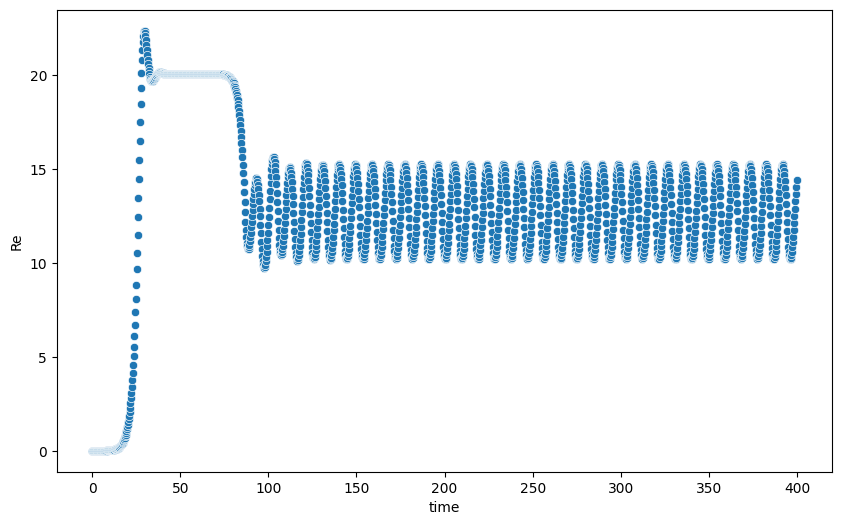

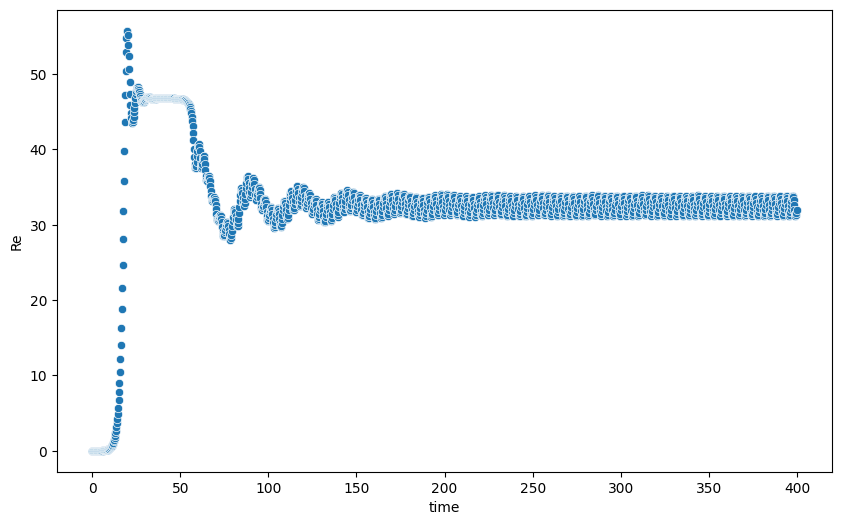

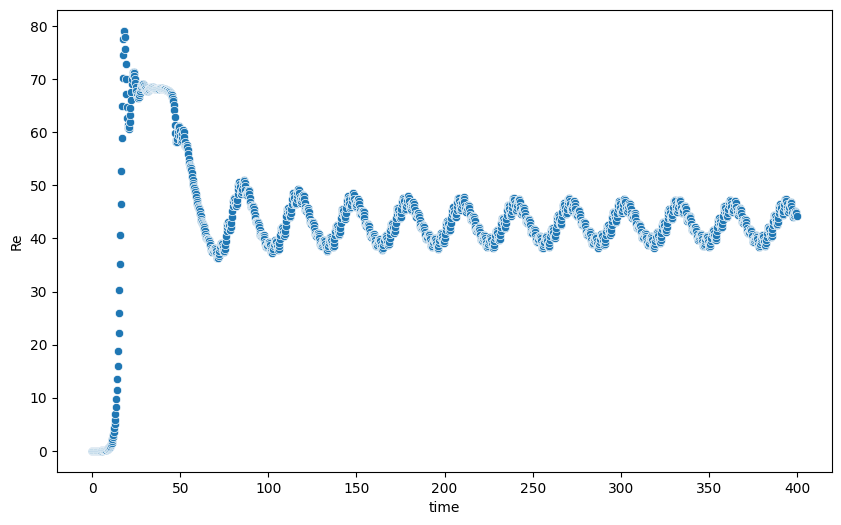

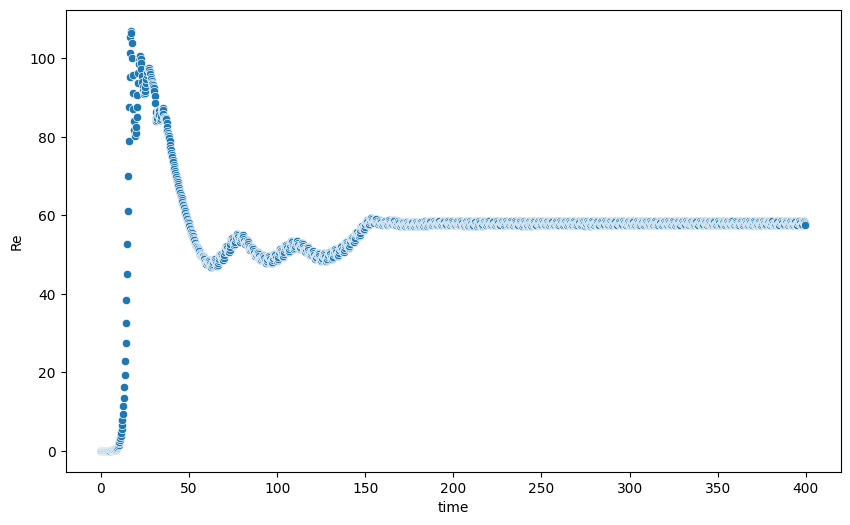

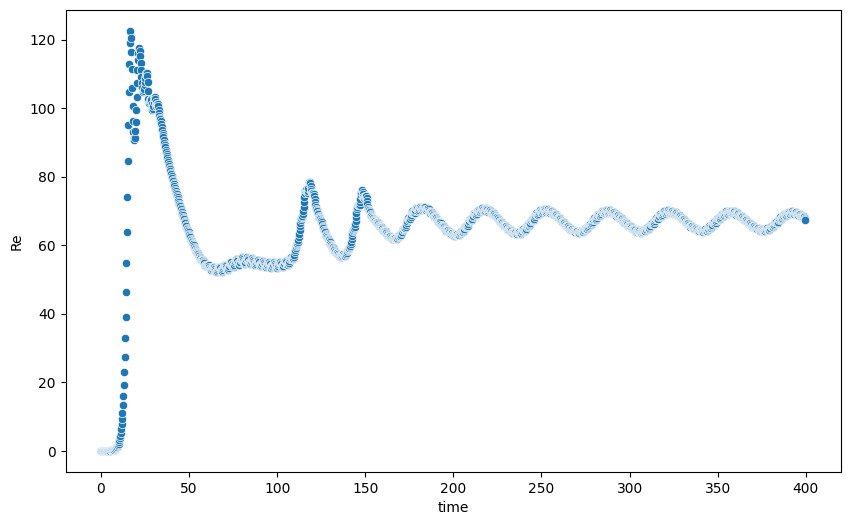

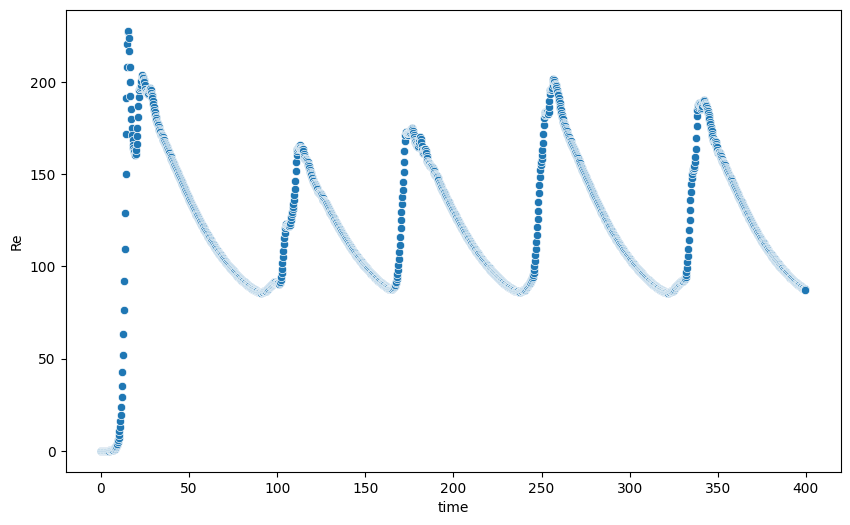

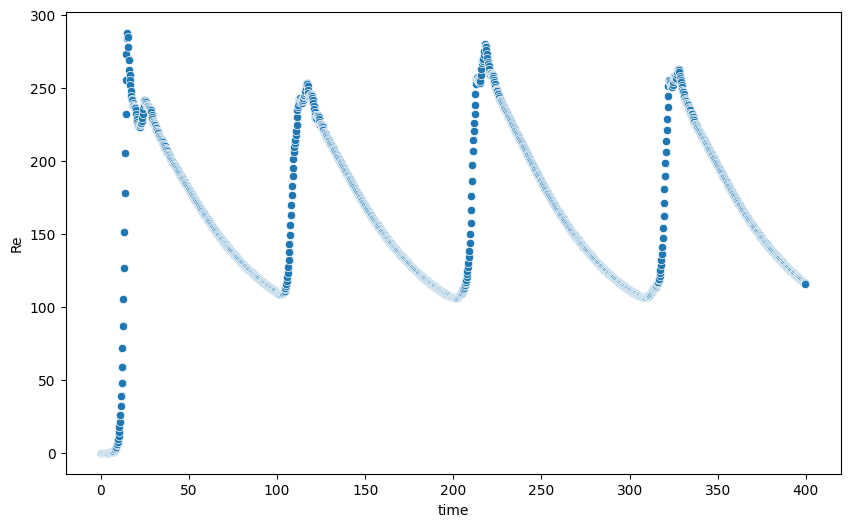

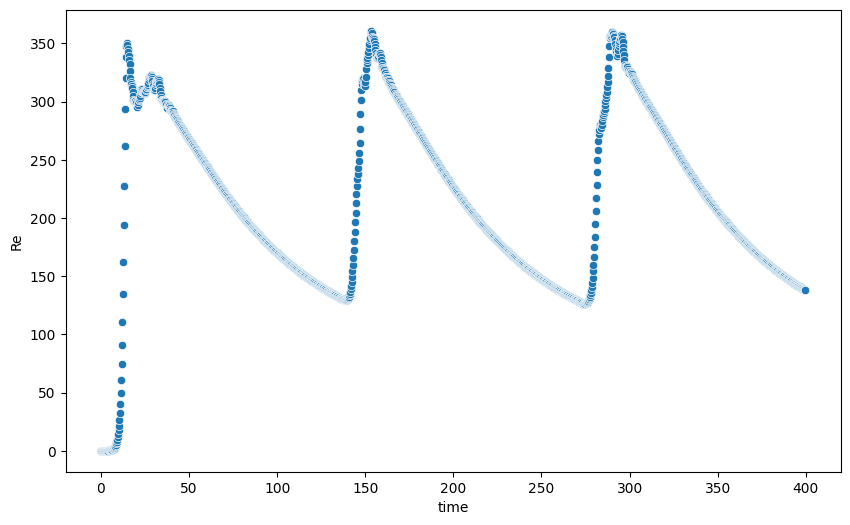

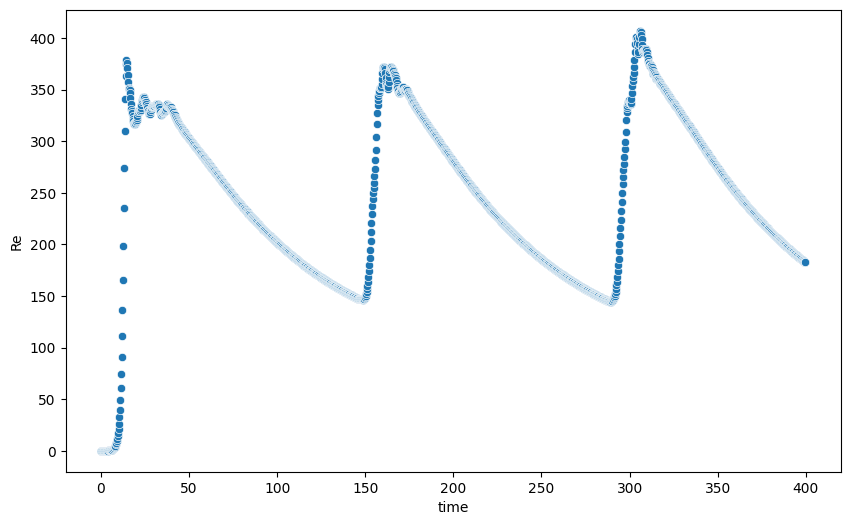

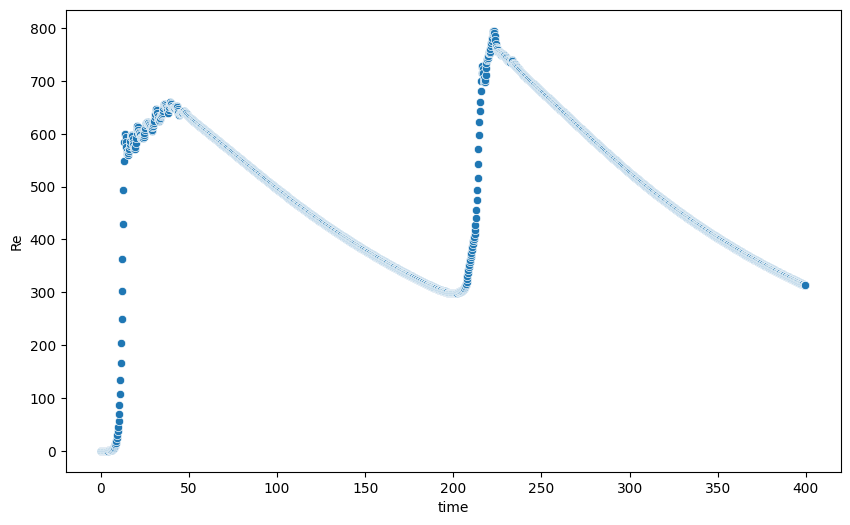

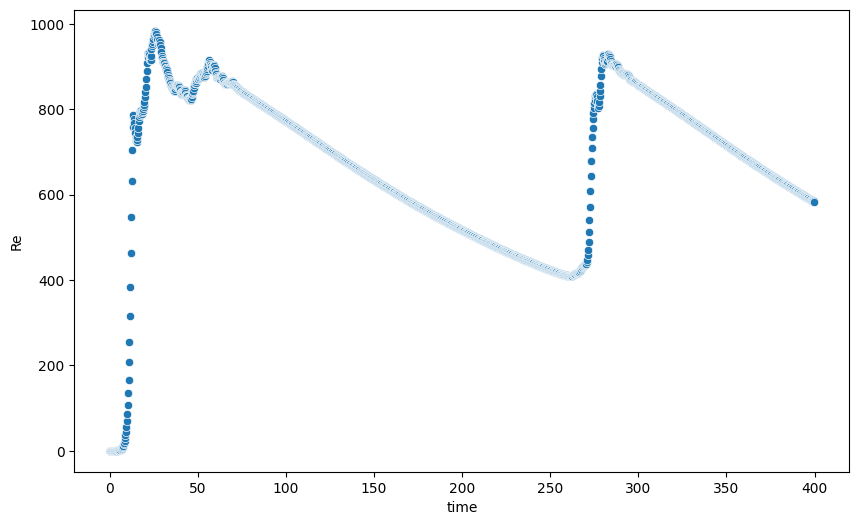

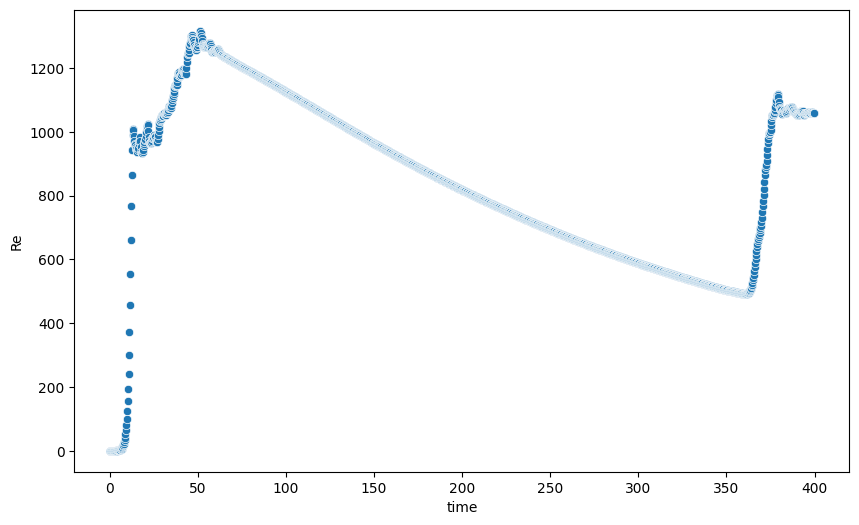

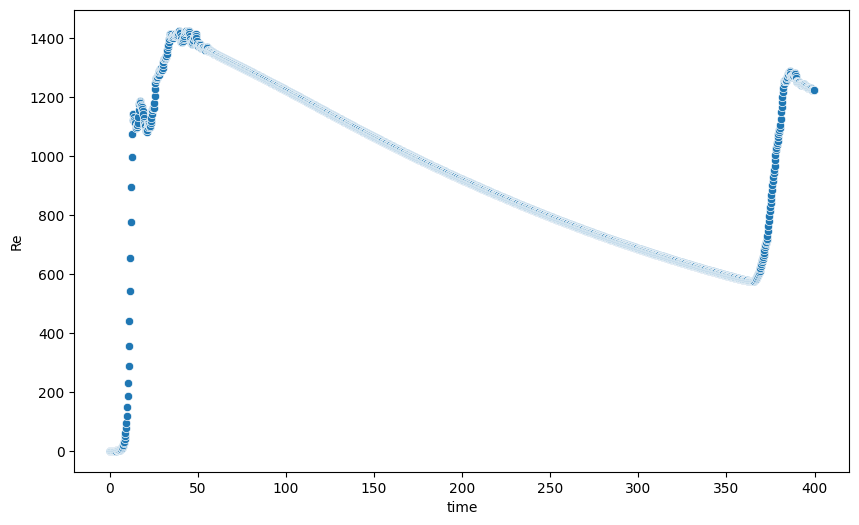

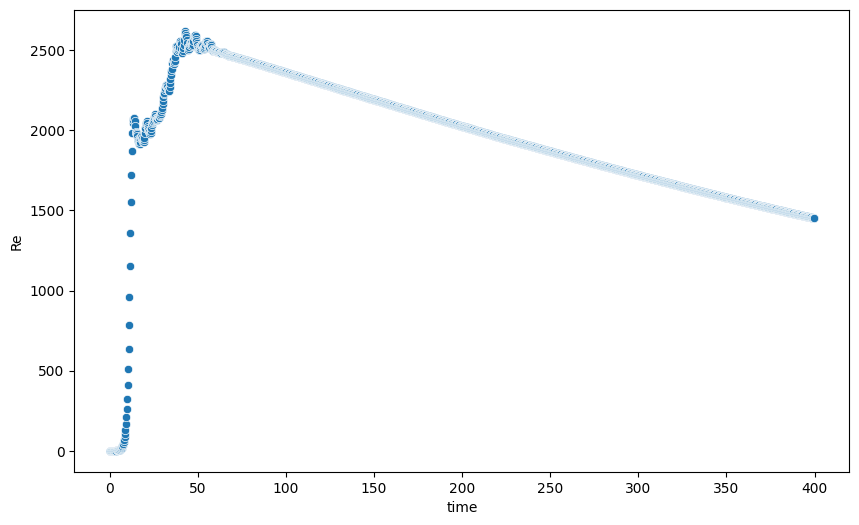

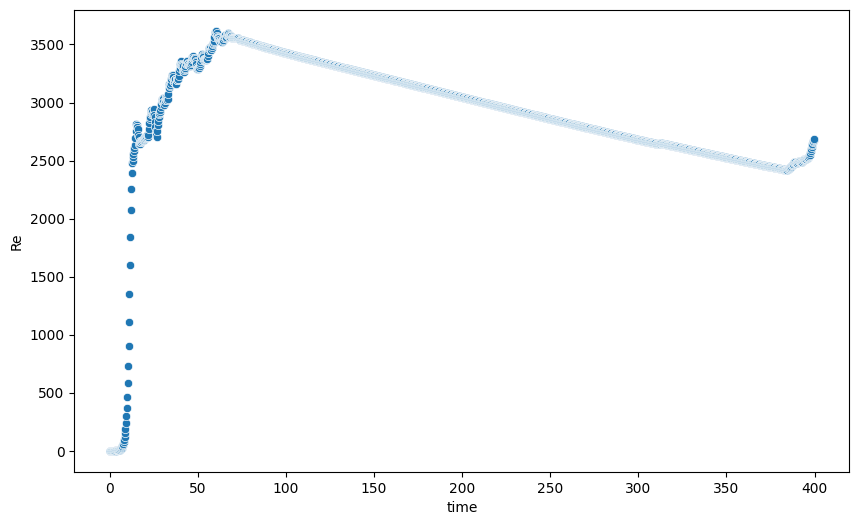

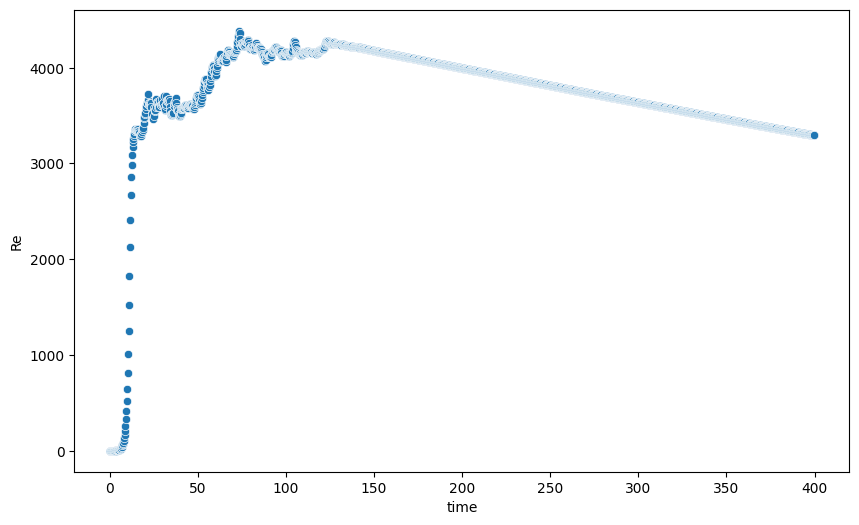

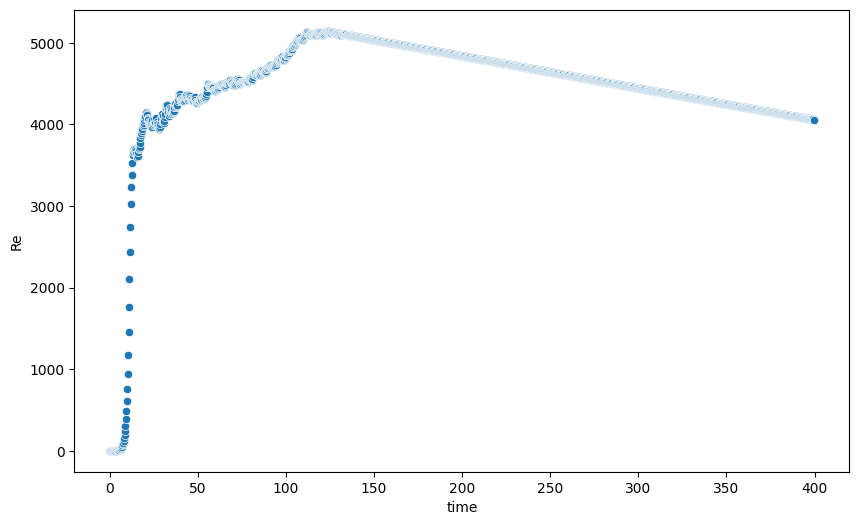

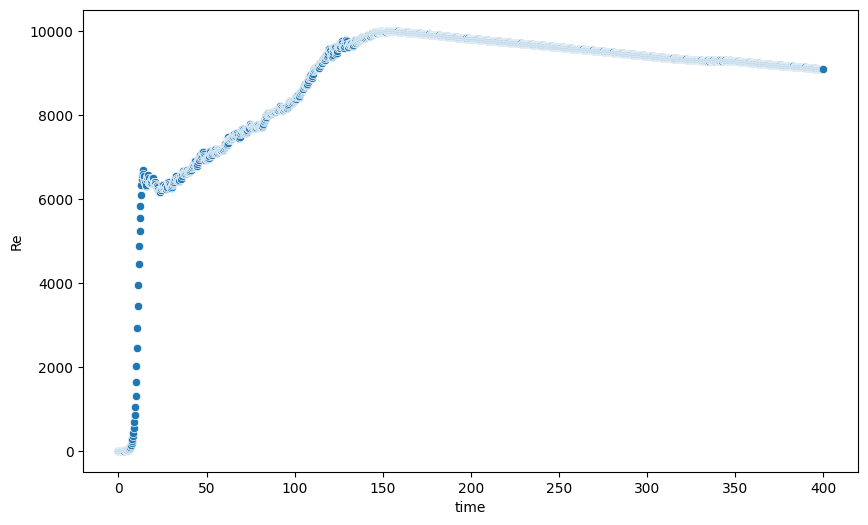

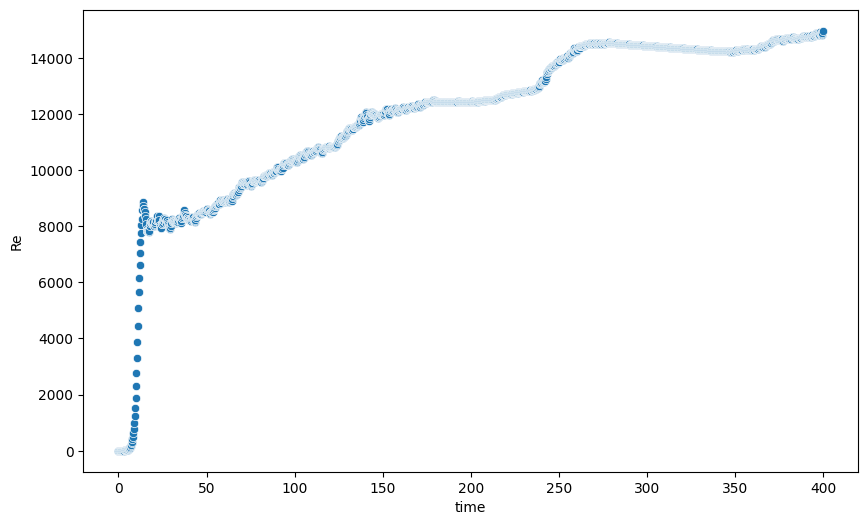

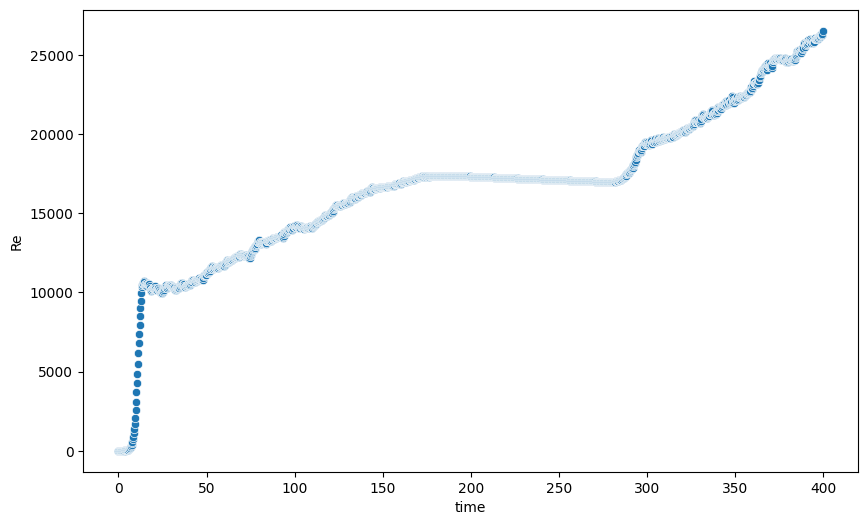

In [5]:
for i in range(0, 20, 1):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x = df_clean[i]['time'], y = df_clean[i]['Re'])

In [6]:
#SEED = 5

In [7]:

#np.random.seed(SEED)
#tf.random.set_seed(SEED)
#random.seed(SEED)

# Standardize features 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Log-transform the target and scale it
log_y = np.log1p(y_train)
scaler_y = StandardScaler()
y_train_log = scaler_y.fit_transform(log_y.values.reshape(-1, 1)).flatten()

# Heteroscedastic loss function (adjusted for log-transformed target)
def heteroscedastic_loss(y_true, y_pred):
    mu = y_pred[:, 0]  # Mean prediction (log-space)
    log_var = y_pred[:, 1]
    precision = tf.exp(log_var)  # Inverse variance
    return tf.reduce_mean(0.5 * (tf.math.log(2 * np.pi) + log_var + (y_true - mu) ** 2 / precision))



loss_fn = keras.losses.Huber(delta=10)  # Adjust delta to control sensitivity

reg = 0.0001
# Build the neural network
input_layer = keras.Input(shape=(2,))
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(input_layer)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001))(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0005))(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)

#x = layers.Dropout(0.2)(x)  
output_layer = layers.Dense(2)(x)  # Two outputs: mean and log variance

model = keras.Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss= heteroscedastic_loss)


# Train the model with validation split
history = model.fit(X_train, y_train_log, epochs=100, batch_size=128)


Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.7552
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.3592
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.4968
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.5491
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.5752
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.6796
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.7584
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.7087
Epoch 9/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.7830
Epoch 10/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.7961
Epoch 11/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.8259
Epoch 12/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.8306
Epoch 13/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.8498
Epoch 14/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: -0.8452
Epoch 15/100
750/750 ━━━━━━━━━

In [8]:
test_df = pd.DataFrame()
path8 = "FS_analysis_4e6/FS_analysis_4e6_s1.h5"

test_df = h5_to_dataframe(path8, test_df)
Ral_number = np.ones(1601)*4e6
test_df['Ra_num'] = Ral_number.tolist()

test_df2 = pd.DataFrame()
path12 = "FS_analysis_6e7/FS_analysis_6e7_s1.h5"

test_df2 = h5_to_dataframe(path12, test_df2)
Ral_number = np.ones(1601)*6e7
test_df2['Ra_num'] = Ral_number.tolist()

test_df3 = pd.DataFrame()
path14 = "FS_analysis_2e8/FS_analysis_2e8_s1.h5"

test_df3 = h5_to_dataframe(path14, test_df3)
Ral_number = np.ones(1600)*2e8
test_df3['Ra_num'] = Ral_number.tolist()

In [9]:
test_dfs = [test_df, test_df2, test_df3]
y_predictions = []
std_predictions = []
avg_re = []
mae_perc = []
for df in test_dfs:
    X_test = df[features]
    X_test = scaler.transform(X_test)
    y_pred = model.predict(X_test)

    mu_pred, log_var_pred = y_pred[:, 0], y_pred[:, 1]
    sigma_pred = np.exp(log_var_pred / 2)  # Convert log variance to standard deviation
   
    mu_pred = scaler_y.inverse_transform(mu_pred.reshape(-1, 1)).flatten()
    sigma_pred = scaler_y.inverse_transform(sigma_pred.reshape(-1, 1)).flatten()

    mu_pred = np.expm1(mu_pred)
    mu_pred = np.abs(mu_pred)
    #sigma_pred = np.expm1(sigma_pred)

    y_predictions.append(mu_pred)
    std_predictions.append(sigma_pred)
    MAE = mean_absolute_error(df['Re'], mu_pred)
    print(MAE)
    mean = np.mean(df['Re'])
    avg_re.append(mean)
    mae_perc.append(MAE/mean)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
43.44240372105498
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
191.65831341465008
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
238.04796094286587


In [10]:
print(avg_re)
print(f'average mae error {np.mean(mae_perc)}')

[np.float64(588.5279930866868), np.float64(3172.3165852021084), np.float64(6482.096398419143)]
average mae error 0.056985052357613454


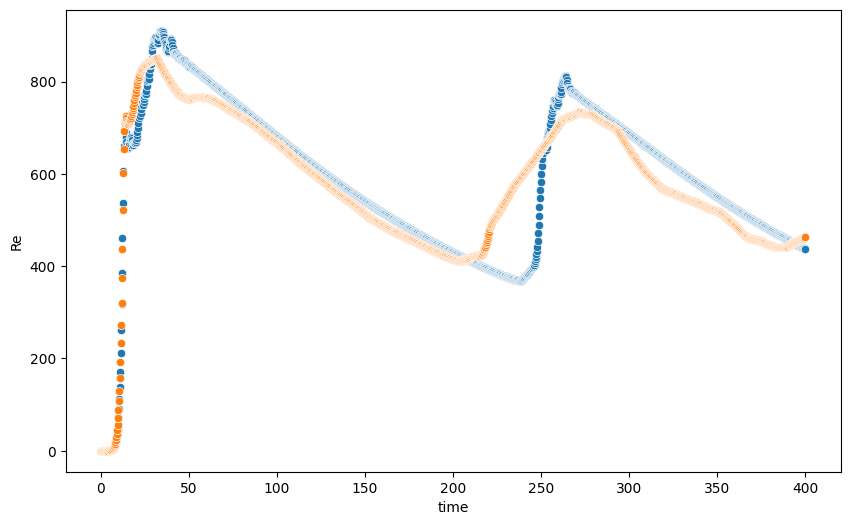

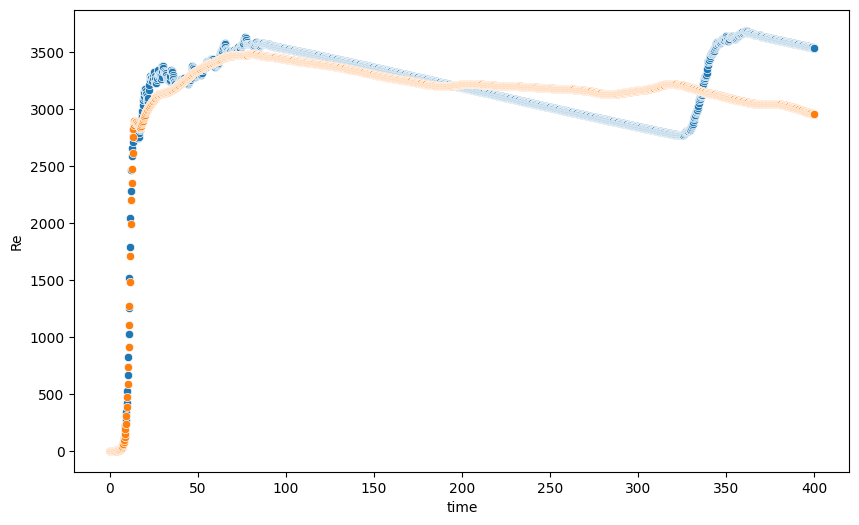

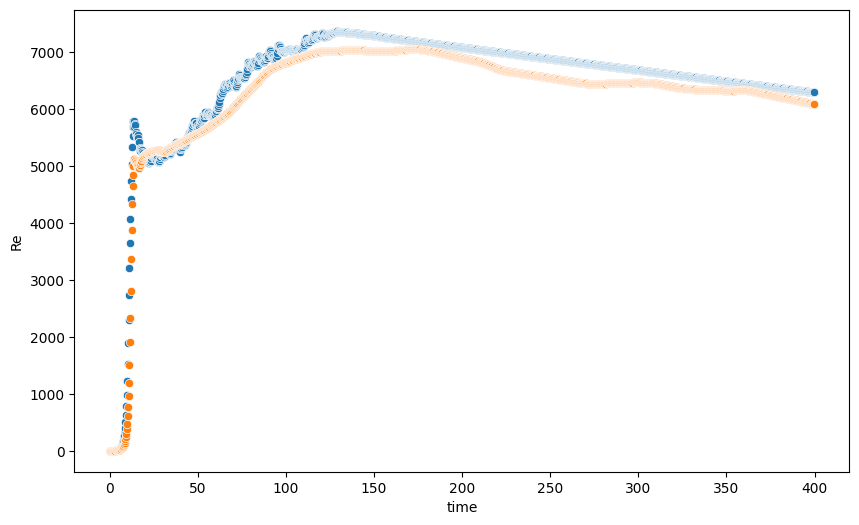

In [11]:
for x, df in enumerate(test_dfs):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x = df['time'], y = df['Re'] )
    sns.scatterplot(x = df['time'], y = y_predictions[x])